In [ ]:
# Team 23 Mango Leaf Disease Detection
# Vishant Garg 102215234
# Kashish Goyal 102215050
# Harshvardhan Singh Shekhawat 102215195
# Rochika Garg 102215262


# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    break


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session








/kaggle/input


In [ ]:
# -------------------------
# Mango Leaf Disease Classification
# -------------------------

import os
import re
import random
import math
from collections import Counter
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preproc
import matplotlib.pyplot as plt
import seaborn as sns

E0000 00:00:1763981183.807922      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763981183.861794      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [ ]:
# -------------------------
# GPU & Determinism
# -------------------------
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as e:
            print("Memory growth error:", e)

strategy = tf.distribute.MirroredStrategy()
print(f'Number of devices: {strategy.num_replicas_in_sync}')

from tensorflow.data import Options
from tensorflow.data.experimental import AutoShardPolicy
DS_OPTIONS = Options()
DS_OPTIONS.experimental_distribute.auto_shard_policy = AutoShardPolicy.DATA
DS_OPTIONS.deterministic = True

K.clear_session()
SEED = 123
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Num GPUs Available: 1
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Number of devices: 1


I0000 00:00:1763981198.502483      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
# -------------------------
# PATHS & GLOBALS (use your dataset paths)
# -------------------------
AUG_DIR  = "/kaggle/input/mango-dataset/Mango Dataset/Mango Dataset/Augmented Image"
PROC_DIR = "/kaggle/input/mango-dataset/Mango Dataset/Mango Dataset/process data"
GLOBAL_BATCH_SIZE = 64   # adjust if memory limited
IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
# -------------------------
# CLASSES
# -------------------------
CANONICAL = [
    "Anthracnose",
    "Bacterial Canker",
    "Cutting Weevil",
    "Die Back",
    "Gall Midge",
    "Healthy",
    "Powdery Mildew",
    "Sooty Mould",
]
canon_index = {" ".join(c.lower().split()): i for i, c in enumerate(CANONICAL)} #maps class names
num_classes = len(CANONICAL)
def norm_name(s): return " ".join(s.lower().split()) #cleans the class name

def make_map(local_names): #matches the class names with directories
    vec, missing = [], []
    for n in local_names:
        key = norm_name(n)
        if key in canon_index: vec.append(canon_index[key])
        else: missing.append(n)
    if missing:
        raise RuntimeError(f"Unmatched class folders {missing} vs canonical {CANONICAL}")
    return tf.constant(vec, tf.int32)

In [ ]:
# -------------------------
# List files
# -------------------------
def list_files_by_class(root):
    classes = sorted([d for d in tf.io.gfile.listdir(root)
                      if tf.io.gfile.isdir(os.path.join(root, d))])
    return {c: tf.io.gfile.glob(os.path.join(root, c, "*")) for c in classes}

aug_files  = list_files_by_class(AUG_DIR)
proc_files = list_files_by_class(PROC_DIR)

print("Aug classes:", sorted(aug_files.keys()))
print("Proc classes:", sorted(proc_files.keys()))

_ = make_map(sorted(aug_files.keys()))
_ = make_map(sorted(proc_files.keys()))

Aug classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Proc classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [ ]:
# -------------------------
# Mix + Group
# -------------------------
_AUG_TOKENS = ("aug", "flip", "rotate", "zoom", "contrast", "brightness",
               "shear", "gauss", "noise", "crop", "shift")

def stem_group(basename):
    stem = os.path.splitext(basename)[0]
    s = stem.lower()
    for tok in _AUG_TOKENS:
        m = re.search(rf"([_\-\.]{tok}\b)", s)
        if m:
            s = s[:m.start()]
            break
    s = re.sub(r"([_\-\.])\d{1,4}$", "", s)
    return s if s else stem

all_paths, all_labels, all_groups = [], [], []
def add_root(root_dict):
    for cname, files in root_dict.items():
        y = canon_index[norm_name(cname)]
        for p in files:
            all_paths.append(p)
            all_labels.append(y)
            all_groups.append(f"{cname}:{stem_group(os.path.basename(p))}")

add_root(aug_files)
add_root(proc_files)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)
all_groups = np.array(all_groups)

print(f"TOTAL pooled files: {len(all_paths)}")

TOTAL pooled files: 15083


In [ ]:
# -------------------------
# Pre-clean images (deterministic)
# -------------------------
def quick_is_good(path):
    try:
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.convert_image_dtype(img, tf.float32)
        h = int(img.shape[0]); w = int(img.shape[1])
        if h < 32 or w < 32: return False
        mean = float(tf.reduce_mean(img).numpy())
        var  = float(tf.math.reduce_variance(img).numpy())
        if not np.isfinite(mean) or not np.isfinite(var): return False
        if not (0.02 < mean < 0.98): return False
        if var <= 5e-5: return False
        return True
    except Exception:
        return False

good_mask = np.array([quick_is_good(p) for p in all_paths], dtype=bool)
if not good_mask.any():
    raise RuntimeError("No valid images after pre-clean!")
all_paths_clean  = all_paths[good_mask]
all_labels_clean = all_labels[good_mask]
all_groups_clean = all_groups[good_mask]
print(f"Valid images after pre-clean: {len(all_paths_clean)} / {len(all_paths)}")

Valid images after pre-clean: 12923 / 15083


In [ ]:
# -------------------------
# StratifiedGroupKFold 60/20/20 (deterministic)
# -------------------------
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(sgkf.split(X=all_paths_clean, y=all_labels_clean, groups=all_groups_clean))
val_idx  = folds[0][1]
test_idx = folds[1][1]
used = set(val_idx.tolist() + test_idx.tolist())
train_idx = np.array([i for i in range(len(all_paths_clean)) if i not in used], dtype=np.int64)

train_paths, train_labels = all_paths_clean[train_idx], all_labels_clean[train_idx]
val_paths,   val_labels   = all_paths_clean[val_idx],   all_labels_clean[val_idx]
test_paths,  test_labels  = all_paths_clean[test_idx],  all_labels_clean[test_idx]

print(f"Split sizes -> Train:{len(train_paths)}  Val:{len(val_paths)}  Test:{len(test_paths)}")

Split sizes -> Train:7690  Val:2604  Test:2629


In [ ]:
# -------------------------
# Preprocess functions
# -------------------------
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preproc

def preprocess_train(image):
    image = tf.image.resize(image, [max(IMG_SIZE), max(IMG_SIZE)], antialias=True)
    image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE[0], IMG_SIZE[1])
    image = tf.cast(image, tf.float32) / 255.0
    # deterministic augmentations with stateless ops
    image = tf.image.random_flip_left_right(image, seed=SEED)
    image = tf.image.random_flip_up_down(image,   seed=SEED)
    image = tf.image.stateless_random_brightness(image, max_delta=0.1, seed=[SEED, 1])
    image = tf.image.stateless_random_contrast(image, lower=0.9, upper=1.1, seed=[SEED, 2])
    image = tf.clip_by_value(image, 0., 1.)
    image = mnv2_preproc(image * 255.0)  # [-1,1] expected by mobilenet
    return image

def preprocess_eval(image):
    image = tf.image.resize(image, IMG_SIZE, antialias=True)
    image = tf.cast(image, tf.float32)
    image = mnv2_preproc(image)          # mobilenet preprocess (input 0-255)
    return image

In [ ]:
# -------------------------
# Build tf.data datasets (deterministic)
# -------------------------
def make_ds(paths, labels, training: bool):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    def _decode(p, y):
        b = tf.io.read_file(p)
        img = tf.io.decode_image(b, channels=3, expand_animations=False)
        return img, y
    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x,y: (preprocess_train(x), y), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
        ds = ds.batch(GLOBAL_BATCH_SIZE, drop_remainder=True)
        ds = ds.repeat()
    else:
        ds = ds.map(lambda x,y: (preprocess_eval(x), y), num_parallel_calls=AUTOTUNE)
        ds = ds.batch(GLOBAL_BATCH_SIZE, drop_remainder=False)
    ds = ds.with_options(DS_OPTIONS)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, train_labels, training=True)
val_ds   = make_ds(val_paths,   val_labels,   training=False)
test_ds  = make_ds(test_paths,  test_labels,  training=False)

train_steps = len(train_paths) // GLOBAL_BATCH_SIZE
val_steps   = math.ceil(len(val_paths) / GLOBAL_BATCH_SIZE)
test_steps  = math.ceil(len(test_paths) / GLOBAL_BATCH_SIZE)
print(f"Steps -> train:{train_steps}  val:{val_steps}  test:{test_steps}")

Steps -> train:120  val:41  test:42


In [ ]:
# -------------------------
# Class weights
# -------------------------
cnt = Counter(train_labels.tolist())
total_train = sum(cnt.values())
class_weights = {c: total_train / (num_classes * max(cnt.get(c, 1), 1)) for c in range(num_classes)}
print("Train distribution:", dict(cnt))
print("Class weights:", class_weights)

Train distribution: {0: 1189, 1: 1464, 2: 500, 3: 695, 4: 1433, 5: 869, 6: 584, 7: 956}
Class weights: {0: 0.8084524810765349, 1: 0.6565915300546448, 2: 1.9225, 3: 1.3830935251798562, 4: 0.6707955338450803, 5: 1.106156501726122, 6: 1.6459760273972603, 7: 1.0054916317991631}


In [ ]:
# -------------------------
# Utility: training & evaluation wrapper (keeps repeats safe)
# -------------------------
def get_common_callbacks(prefix):
    return [
        EarlyStopping(monitor='val_sparse_accuracy', patience=6, restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{prefix}_best.keras', monitor='val_sparse_accuracy', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]

def train_and_evaluate(model_builder, name,
                       epochs_phase1=15, epochs_phase2=15,
                       fine_tune=False, fine_tune_at=None,
                       base_trainable_after=False,
                       batch_size=GLOBAL_BATCH_SIZE):
    """
    model_builder -> function that returns (model, base_model_or_None)
    name -> prefix for checkpoints/plots
    returns -> (model, history1, history2_or_None)
    """
    print("\n" + "="*60)
    print(f"EXPERIMENT: {name}")
    print("="*60)

    model, base = model_builder()  # model already compiled inside builder
    model.summary()

    callbacks1 = get_common_callbacks(name + "_phase1")

    # Phase 1 training (could be frozen base depending on builder)
    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs_phase1,
        steps_per_epoch=train_steps,
        validation_steps=val_steps,
        class_weight=class_weights,
        callbacks=callbacks1,
        verbose=1
    )

    # load best from phase1
    ckpt1 = f'{name}_phase1_best.keras'
    # ModelCheckpoint saved under name_phase1_best.keras if used; but get_common_callbacks uses {prefix}_best.keras
    if os.path.exists(f'{name}_phase1_best.keras'):
        model.load_weights(f'{name}_phase1_best.keras')
    elif os.path.exists(f'{name}_best.keras'):
        model.load_weights(f'{name}_best.keras')

    history2 = None
    if fine_tune and base is not None:
        print("\n--- Fine-tuning phase ---")

        # IMPORTANT: wrap fine-tuning under strategy.scope()
        with strategy.scope():
            base.trainable = True
            if fine_tune_at is None:
                fine_tune_at = int(len(base.layers) * 0.7)

            # freeze lower part
            for layer in base.layers[:fine_tune_at]:
                layer.trainable = False

            # recompile with lower LR for fine-tuning
            model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                loss='sparse_categorical_crossentropy',
                metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='sparse_accuracy')]
            )

        callbacks2 = get_common_callbacks(name + "_phase2")

        history2 = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs_phase2,
            steps_per_epoch=train_steps,
            validation_steps=val_steps,
            class_weight=class_weights,
            callbacks=callbacks2,
            verbose=1
        )


        # Load best phase2 if exists
        if os.path.exists(f'{name}_phase2_best.keras'):
            model.load_weights(f'{name}_phase2_best.keras')
        elif os.path.exists(f'{name}_best.keras'):
            model.load_weights(f'{name}_best.keras')

    # Save final model for this experiment
    model.save(f'{name}_final.keras')
    print(f"Saved final model: {name}_final.keras")
    return model, history1, history2

In [ ]:
# -------------------------
# MODEL BUILDERS
# -------------------------
def build_base_cnn():
    # Simple custom CNN trained from scratch (Base model)
    with strategy.scope():
        inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
        x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPool2D()(x)
        x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPool2D()(x)
        x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPool2D()(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)

        model = models.Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='sparse_accuracy')]
        )
    return model, None  # no pretrained base

def build_transfer_mobilenet():
    # Transfer learning with MobileNetV2 (frozen in phase1)
    with strategy.scope():
        inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
        base = MobileNetV2(include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), weights='imagenet')
        base.trainable = False
        x = base(inputs, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)

        model = models.Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='sparse_accuracy')]
        )
    return model, base

def build_hybrid_mobilenet_efficientnet():
    # Hybrid fusion: extract features from both MobileNetV2 & EfficientNetB0 and concat
    with strategy.scope():
        # Inputs
        inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

        # Pretrained backbone A (MobileNetV2)
        base_a = MobileNetV2(include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), weights='imagenet')
        base_a.trainable = False
        feat_a = base_a(inputs, training=False)
        feat_a = layers.GlobalAveragePooling2D()(feat_a)

        # Pretrained backbone B (EfficientNetB0)
        base_b = EfficientNetB0(include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), weights='imagenet')
        base_b.trainable = False
        feat_b = base_b(inputs, training=False)
        feat_b = layers.GlobalAveragePooling2D()(feat_b)

        # Fusion
        x = layers.Concatenate()([feat_a, feat_b])
        x = layers.BatchNormalization()(x)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.5)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)

        model = models.Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='sparse_accuracy')]
        )

        # Return a "combined base" for fine-tuning logic: we will fine-tune all layers of both bases together later if desired.
        # For convenience, return one of the bases (we'll unfreeze entire model for fine-tuning).
    return model, None

In [ ]:
# -------------------------
# TRAIN ALL THREE MODELS (sequentially)
# -------------------------
# Hyperparameters summary (for the Methodology -> Hyperparameters section)
HYPERPARAMETERS = {
    "IMG_SIZE": IMG_SIZE,
    "GLOBAL_BATCH_SIZE": GLOBAL_BATCH_SIZE,
    "SEED": SEED,
    "OPTIMIZER_phase1": "Adam(lr=1e-3)",
    "OPTIMIZER_finetune": "Adam(lr=1e-4)",
    "LOSS": "sparse_categorical_crossentropy",
    "EPOCHS_phase1": 15,
    "EPOCHS_phase2": 15,
    "DROPOUT": [0.4, 0.5],
    "AUGMENTATIONS": ["flip_lr", "flip_ud", "brightness", "contrast (stateless)"],
}
print("Hyperparameters:", HYPERPARAMETERS)

# Train Base CNN (from scratch)
base_cnn_model, base_hist1, base_hist2 = train_and_evaluate(build_base_cnn, name="base_cnn",
                                                            epochs_phase1=20, epochs_phase2=0,
                                                            fine_tune=False)

# Train Transfer MobileNetV2
mobilenet_model, mn_hist1, mn_hist2 = train_and_evaluate(build_transfer_mobilenet, name="mobilenet",
                                                         epochs_phase1=15, epochs_phase2=15,
                                                         fine_tune=True, fine_tune_at=None)

# Train Hybrid (fusion of MobileNetV2 + EfficientNetB0)
hybrid_model, hybrid_hist1, hybrid_hist2 = train_and_evaluate(build_hybrid_mobilenet_efficientnet, name="hybrid_mobilenet_effnet",
                                                              epochs_phase1=15, epochs_phase2=15, fine_tune=False)
# Note: hybrid returns None base; if you want to fine-tune, you can unfreeze whole model and retrain similarly.

Hyperparameters: {'IMG_SIZE': (224, 224), 'GLOBAL_BATCH_SIZE': 64, 'SEED': 123, 'OPTIMIZER_phase1': 'Adam(lr=1e-3)', 'OPTIMIZER_finetune': 'Adam(lr=1e-4)', 'LOSS': 'sparse_categorical_crossentropy', 'EPOCHS_phase1': 15, 'EPOCHS_phase2': 15, 'DROPOUT': [0.4, 0.5], 'AUGMENTATIONS': ['flip_lr', 'flip_ud', 'brightness', 'contrast (stateless)']}

EXPERIMENT: base_cnn


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,248 (508.78 KB)

 Trainable params: 129,288 (505.03 KB)

...

 Trainable params: 1,451,272 (5.54 MB)

 Non-trainable params: 6,314,211 (24.09 MB)

Epoch 1/15


E0000 00:00:1763983956.496256      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.7980 - sparse_accuracy: 0.7151
Epoch 1: val_sparse_accuracy improved from -inf to 0.93088, saving model to hybrid_mobilenet_effnet_phase1_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 100s 439ms/step - loss: 0.7952 - sparse_accuracy: 0.7161 - val_loss: 0.2061 - val_sparse_accuracy: 0.9309 - learning_rate: 0.0010
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.1992 - sparse_accuracy: 0.9198
Epoch 2: val_sparse_accuracy improved from 0.93088 to 0.96467, saving model to hybrid_mobilenet_effnet_phase1_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 74s 505ms/step - loss: 0.1991 - sparse_accuracy: 0.9199 - val_loss: 0.1189 - val_sparse_accuracy: 0.9647 - learning_rate: 0.0010
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.1234 - sparse_accuracy: 0.9531
Epoch 3: val_sparse_accuracy improved from 0.96467 to 0.96505, saving model to hybrid_mobilenet_effnet_phase1_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 40s 331ms/step - los

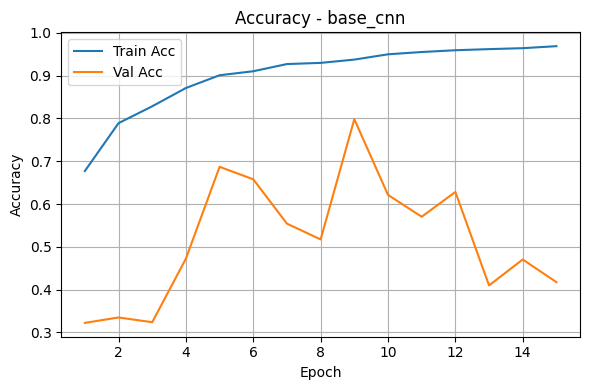

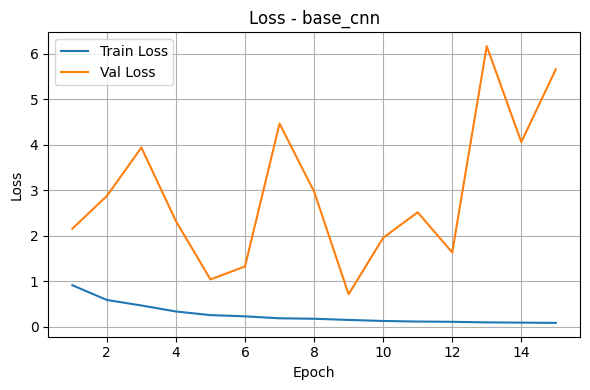

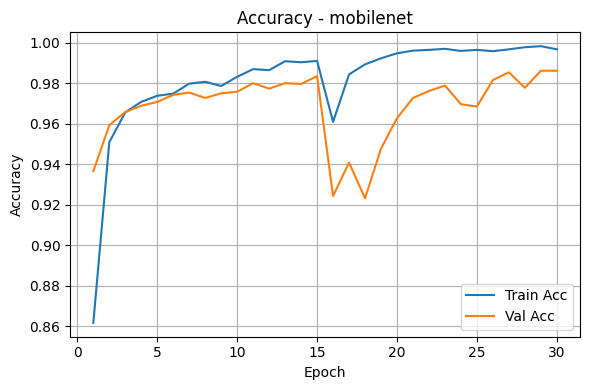

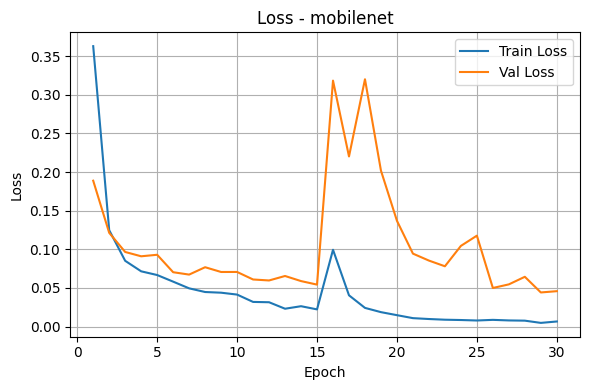

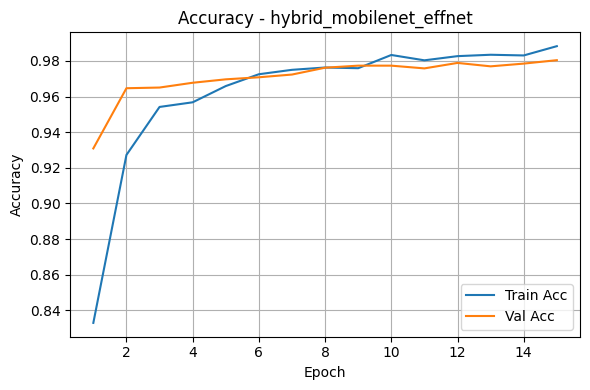

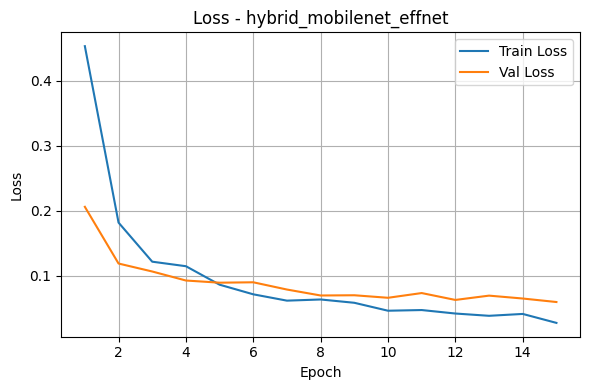

In [ ]:
# -------------------------
# Helper: plot history and save
# -------------------------
def plot_history_and_save(name, h1, h2=None):
    acc = list(h1.history['sparse_accuracy'])
    val_acc = list(h1.history['val_sparse_accuracy'])
    loss = list(h1.history['loss'])
    val_loss = list(h1.history['val_loss'])
    if h2:
        acc += list(h2.history['sparse_accuracy'])
        val_acc += list(h2.history['val_sparse_accuracy'])
        loss += list(h2.history['loss'])
        val_loss += list(h2.history['val_loss'])
    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title(f'Accuracy - {name}'); plt.grid(True); plt.legend()
    plt.tight_layout()
    plt.savefig(f"{name}_accuracy.png")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'Loss - {name}'); plt.grid(True); plt.legend()
    plt.tight_layout()
    plt.savefig(f"{name}_loss.png")
    plt.show()

# Save & plot histories
plot_history_and_save("base_cnn", base_hist1, base_hist2)
plot_history_and_save("mobilenet", mn_hist1, mn_hist2)
plot_history_and_save("hybrid_mobilenet_effnet", hybrid_hist1, hybrid_hist2)


EVALUATING base_cnn ON TEST SET

Test Accuracy: 80.75%
Test Loss: 0.7149


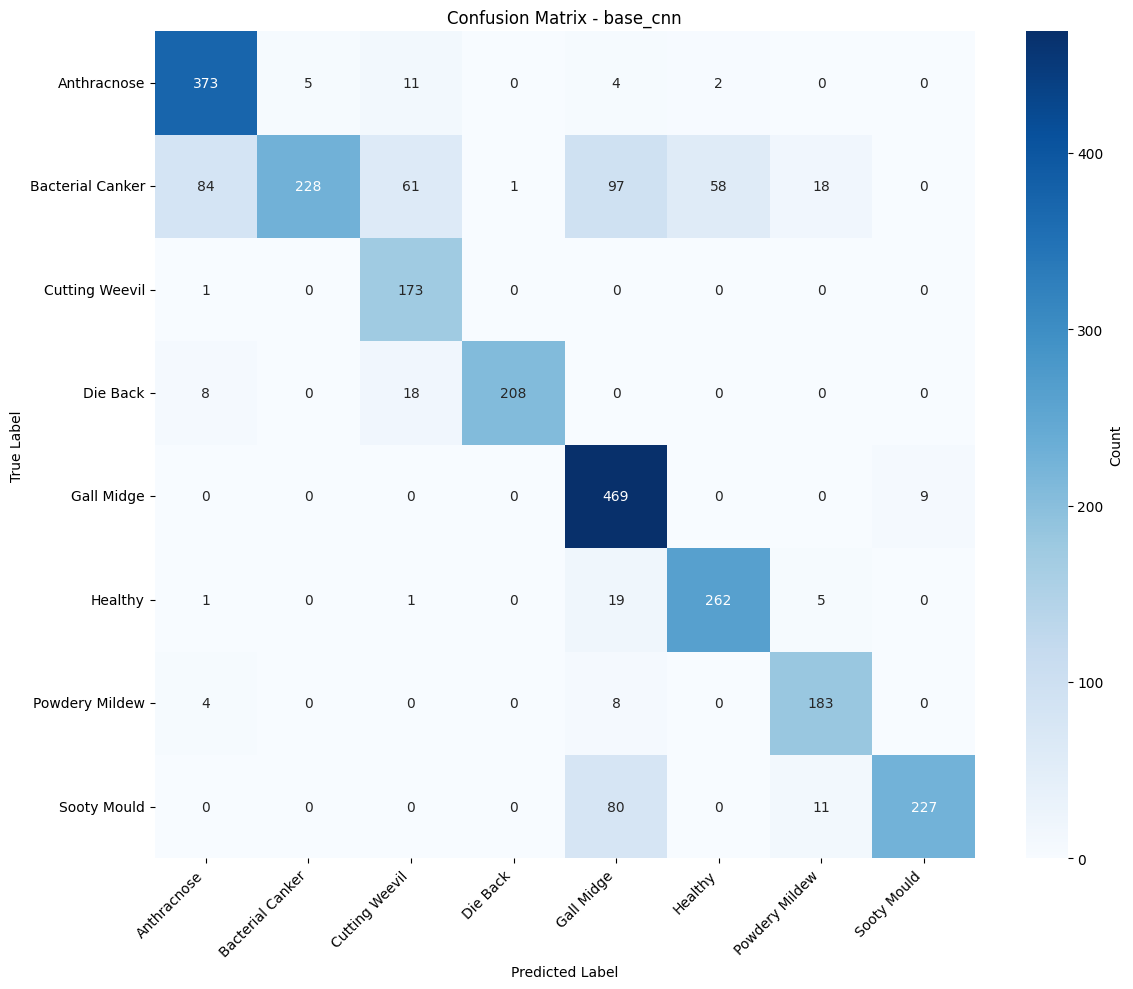


CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     Anthracnose     0.7919    0.9443    0.8614       395
Bacterial Canker     0.9785    0.4168    0.5846       547
  Cutting Weevil     0.6553    0.9943    0.7900       174
        Die Back     0.9952    0.8889    0.9391       234
      Gall Midge     0.6928    0.9812    0.8121       478
         Healthy     0.8137    0.9097    0.8590       288
  Powdery Mildew     0.8433    0.9385    0.8883       195
     Sooty Mould     0.9619    0.7138    0.8195       318

        accuracy                         0.8075      2629
       macro avg     0.8416    0.8484    0.8193      2629
    weighted avg     0.8485    0.8075    0.7937      2629


PER-CLASS ACCURACY
Anthracnose         : 94.43%
Bacterial Canker    : 41.68%
Cutting Weevil      : 99.43%
Die Back            : 88.89%
Gall Midge          : 98.12%
Healthy             : 90.97%
Powdery Mildew      : 93.85%
Sooty Mould         : 71.38%
Saved classification repor

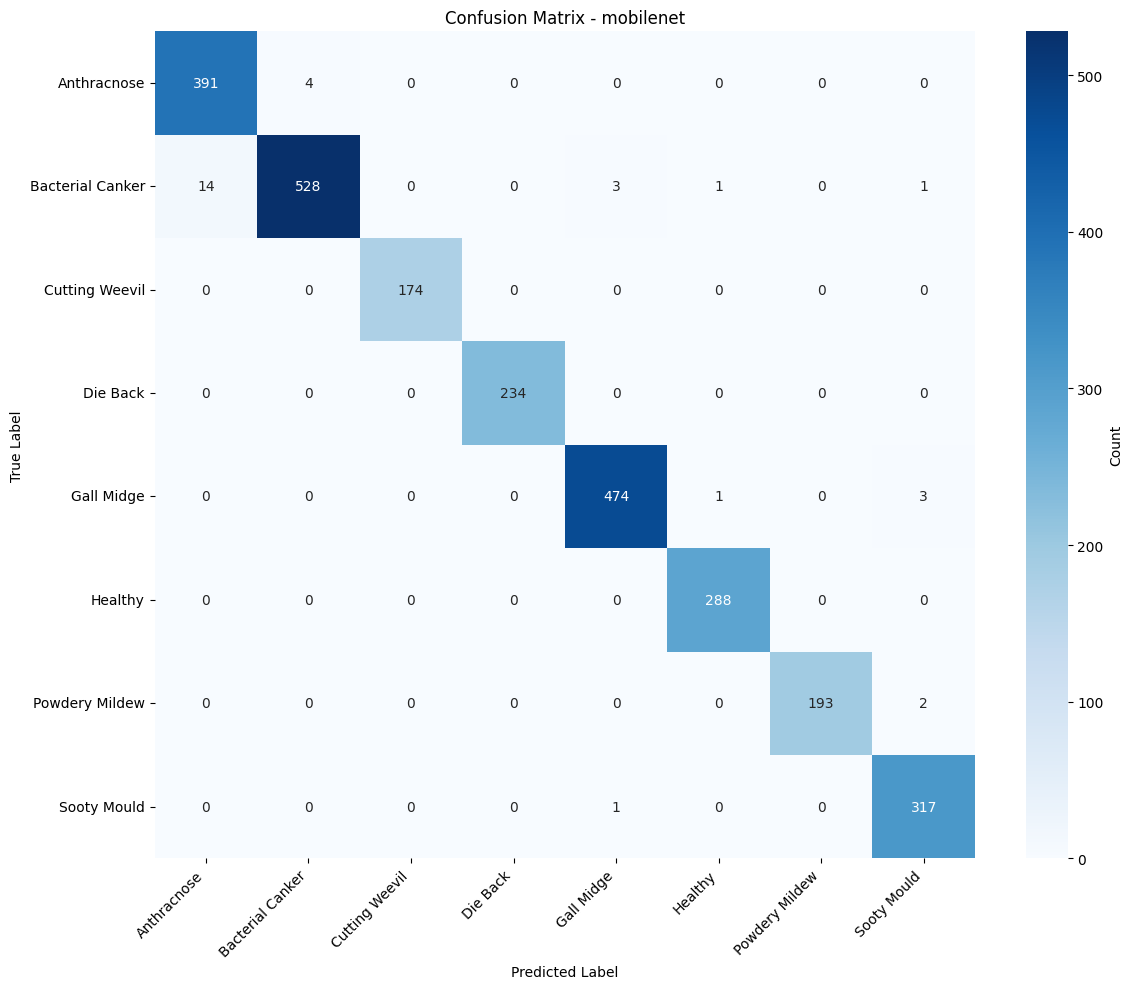


CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     Anthracnose     0.9654    0.9899    0.9775       395
Bacterial Canker     0.9925    0.9653    0.9787       547
  Cutting Weevil     1.0000    1.0000    1.0000       174
        Die Back     1.0000    1.0000    1.0000       234
      Gall Midge     0.9916    0.9916    0.9916       478
         Healthy     0.9931    1.0000    0.9965       288
  Powdery Mildew     1.0000    0.9897    0.9948       195
     Sooty Mould     0.9814    0.9969    0.9891       318

        accuracy                         0.9886      2629
       macro avg     0.9905    0.9917    0.9910      2629
    weighted avg     0.9887    0.9886    0.9886      2629


PER-CLASS ACCURACY
Anthracnose         : 98.99%
Bacterial Canker    : 96.53%
Cutting Weevil      : 100.00%
Die Back            : 100.00%
Gall Midge          : 99.16%
Healthy             : 100.00%
Powdery Mildew      : 98.97%
Sooty Mould         : 99.69%
Saved classification re

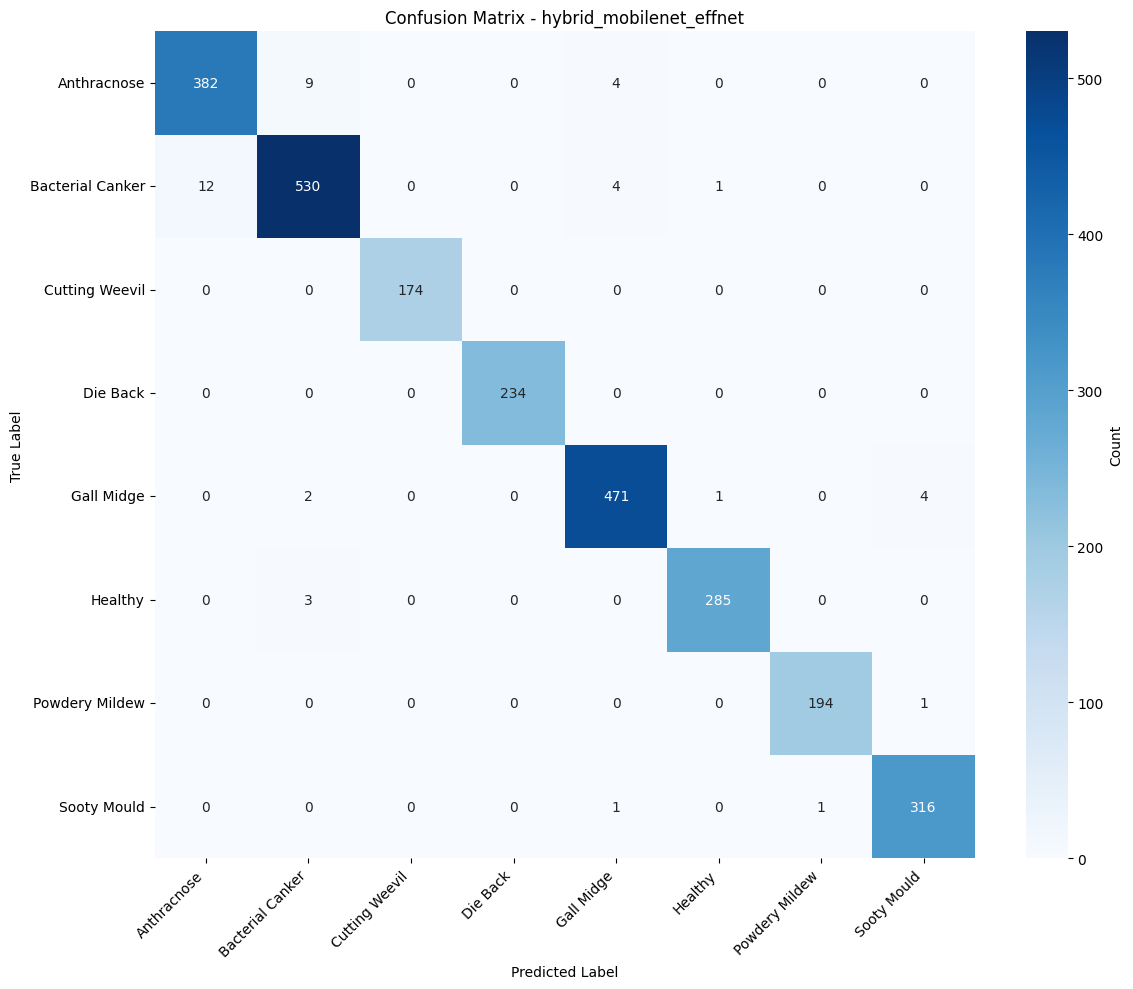


CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     Anthracnose     0.9695    0.9671    0.9683       395
Bacterial Canker     0.9743    0.9689    0.9716       547
  Cutting Weevil     1.0000    1.0000    1.0000       174
        Die Back     1.0000    1.0000    1.0000       234
      Gall Midge     0.9812    0.9854    0.9833       478
         Healthy     0.9930    0.9896    0.9913       288
  Powdery Mildew     0.9949    0.9949    0.9949       195
     Sooty Mould     0.9844    0.9937    0.9890       318

        accuracy                         0.9836      2629
       macro avg     0.9872    0.9874    0.9873      2629
    weighted avg     0.9836    0.9836    0.9836      2629


PER-CLASS ACCURACY
Anthracnose         : 96.71%
Bacterial Canker    : 96.89%
Cutting Weevil      : 100.00%
Die Back            : 100.00%
Gall Midge          : 98.54%
Healthy             : 98.96%
Powdery Mildew      : 99.49%
Sooty Mould         : 99.37%
Saved classification rep

In [ ]:
# -------------------------
# Evaluation function (test dataset, confusion matrix, report)
# -------------------------
def evaluate_and_report(model, name):
    print("\n" + "="*50)
    print(f"EVALUATING {name} ON TEST SET")
    print("="*50)
    test_loss, test_acc = model.evaluate(test_ds, steps=test_steps, verbose=0)
    print(f"\nTest Accuracy: {test_acc*100:.2f}%")
    print(f"Test Loss: {test_loss:.4f}")

    # Predictions (collect)
    y_true, y_pred = [], []
    for images, labels in test_ds.take(test_steps):
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    y_true = np.array(y_true); y_pred = np.array(y_pred)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CANONICAL, yticklabels=CANONICAL,
                cbar_kws={'label': 'Count'})
    plt.xlabel("Predicted Label"); plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {name}"); plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.savefig(f"{name}_confusion.png"); plt.show()

    print("\nCLASSIFICATION REPORT")
    report = classification_report(y_true, y_pred, target_names=CANONICAL, digits=4, zero_division=0)
    print(report)

    print("\nPER-CLASS ACCURACY")
    for i, cname in enumerate(CANONICAL):
        mask = (y_true == i)
        acc = float(np.mean((y_pred[mask] == y_true[mask])) if mask.any() else np.nan)
        print(f"{cname:20s}: {acc*100:.2f}%")

    # Save report to text file for inclusion in report
    with open(f"{name}_classification_report.txt", "w") as f:
        f.write(report)
    print(f"Saved classification report to {name}_classification_report.txt")

# Evaluate each model and save outputs
evaluate_and_report(base_cnn_model, "base_cnn")
evaluate_and_report(mobilenet_model, "mobilenet")
evaluate_and_report(hybrid_model, "hybrid_mobilenet_effnet")

In [ ]:
# -------------------------
# Final: Summaries for Report
# -------------------------
REPORT_SUMMARY = {
    "Title": "Mango Leaf Disease Classification",
    "Background_Summary": "Leaf disease detection helps farmers quickly identify plant issues. Existing approaches include classical image processing + machine learning, CNNs trained from scratch, and transfer-learning from ImageNet pre-trained backbones. Recent research favors transfer learning and ensembling/hybrid feature fusion for small datasets.",
    "Methodology_Summary": "We preprocess images with resizing, stateless deterministic augmentations and normalize to networks' expected ranges. We train three models: a small CNN (base), MobileNetV2 transfer learning (frozen then fine-tuned), and a hybrid feature-fusion model combining MobileNetV2 and EfficientNetB0 feature extractors. Training used stratified-group-splits to avoid leakage, class weights to address imbalance, and deterministic tf.data pipeline.",
    "Training_Details": f"Train/Val/Test splits: {len(train_paths)}/{len(val_paths)}/{len(test_paths)}. Batch size: {GLOBAL_BATCH_SIZE}. Steps per epoch (train): {train_steps}. Random seed: {SEED}. Callback: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau.",
    "Hyperparameters": HYPERPARAMETERS,
    "Files_Saved": [
        "base_cnn_final.keras", "base_cnn_confusion.png", "base_cnn_classification_report.txt",
        "mobilenet_final.keras", "mobilenet_confusion.png", "mobilenet_classification_report.txt",
        "hybrid_mobilenet_effnet_final.keras", "hybrid_mobilenet_effnet_confusion.png", "hybrid_mobilenet_effnet_classification_report.txt"
    ],
}
print("\nReport Summary (for report insertion):")
for k,v in REPORT_SUMMARY.items():
    print(f"- {k}: ", (v if k!="Files_Saved" else ", ".join(v)))

# -------------------------
# Save hyperparameters & experiment summary to JSON for easy inclusion in report
# -------------------------
import json
with open("experiment_summary.json", "w") as f:
    json.dump({"hyperparameters": HYPERPARAMETERS, "summary": REPORT_SUMMARY}, f, indent=2)
print("Saved experiment_summary.json")


Report Summary (for report insertion):
- Title:  Mango Leaf Disease Classification
- Background_Summary:  Leaf disease detection helps farmers quickly identify plant issues. Existing approaches include classical image processing + machine learning, CNNs trained from scratch, and transfer-learning from ImageNet pre-trained backbones. Recent research favors transfer learning and ensembling/hybrid feature fusion for small datasets.
- Methodology_Summary:  We preprocess images with resizing, stateless deterministic augmentations and normalize to networks' expected ranges. We train three models: a small CNN (base), MobileNetV2 transfer learning (frozen then fine-tuned), and a hybrid feature-fusion model combining MobileNetV2 and EfficientNetB0 feature extractors. Training used stratified-group-splits to avoid leakage, class weights to address imbalance, and deterministic tf.data pipeline.
- Training_Details:  Train/Val/Test splits: 7690/2604/2629. Batch size: 64. Steps per epoch (train): 1

In [ ]:
import os, re, random, numpy as np, tensorflow as tf
from sklearn.model_selection import StratifiedGroupKFold

SEED = 123
IMG_SIZE = (224,224)
GLOBAL_BATCH_SIZE = 64

# Paths
AUG_DIR  = "/kaggle/input/mango-dataset/Mango Dataset/Mango Dataset/Augmented Image"
PROC_DIR = "/kaggle/input/mango-dataset/Mango Dataset/Mango Dataset/process data"

CANONICAL = [
    "Anthracnose",
    "Bacterial Canker",
    "Cutting Weevil",
    "Die Back",
    "Gall Midge",
    "Healthy",
    "Powdery Mildew",
    "Sooty Mould",
]
canon_index = {c.lower(): i for i,c in enumerate(CANONICAL)}

def list_files_by_class(root):
    classes = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root,d))])
    return {c: tf.io.gfile.glob(os.path.join(root,c,"*")) for c in classes}

aug_files  = list_files_by_class(AUG_DIR)
proc_files = list_files_by_class(PROC_DIR)

_AUG_TOKENS = ("aug","flip","rotate","zoom","contrast","brightness","shear","gauss","noise","crop","shift")

def stem_group(fname):
    fn = fname.lower()
    fn = os.path.splitext(fn)[0]
    for tok in _AUG_TOKENS:
        if tok in fn:
            idx = fn.index(tok)
            return fn[:idx]
    return fn

all_paths = []
all_labels = []
all_groups = []

def add_files(dic):
    for cname, files in dic.items():
        canonical = cname.lower()
        if canonical not in canon_index: continue
        label = canon_index[canonical]
        for f in files:
            all_paths.append(f)
            all_labels.append(label)
            all_groups.append(cname + ":" + stem_group(os.path.basename(f)))

add_files(aug_files)
add_files(proc_files)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)
all_groups = np.array(all_groups)

# ---- Split with Stratified Group KFold ----
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(sgkf.split(all_paths, all_labels, groups=all_groups))

val_idx  = folds[0][1]
test_idx = folds[1][1]
train_idx = np.setdiff1d(np.arange(len(all_paths)), np.concatenate([val_idx, test_idx]))

test_paths  = all_paths[test_idx]
test_labels = all_labels[test_idx]

print("Test size:", len(test_paths))


Test size: 3541


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preproc

def safe_decode(p):
    img_bytes = tf.io.read_file(p)

    # Try decode; if it fails, return a dummy black image
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])  # required to avoid shape error

    return img

def make_test_dataset(paths, labels):
    def _load(p, y):
        img = safe_decode(p)

        # If img is empty or scalar => replace with black image
        img_shape = tf.shape(img)
        cond = tf.logical_or(img_shape[0] < 1, img_shape[1] < 1)
        img = tf.cond(
            cond,
            lambda: tf.zeros([IMG_SIZE[0], IMG_SIZE[1], 3], dtype=tf.uint8),
            lambda: img
        )

        # Resize & preprocess
        img = tf.image.resize(img, IMG_SIZE, antialias=True)
        img = tf.cast(img, tf.float32)
        img = mnv2_preproc(img)
        return img, y

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(GLOBAL_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds = make_test_dataset(test_paths, test_labels)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def evaluate_model(model_path, name):
    print("\nEvaluating:", name)
    model = tf.keras.models.load_model(model_path)

    y_true = []
    y_pred = []

    for X, y in test_ds:
        pred = model.predict(X, verbose=0)
        y_true.extend(y.numpy())
        y_pred.extend(np.argmax(pred, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro"),
        "Recall": recall_score(y_true, y_pred, average="macro"),
        "F1-Score": f1_score(y_true, y_pred, average="macro")
    }

results = [
    evaluate_model("/kaggle/input/models/keras/default/1/base_cnn_final.keras", "Base CNN"),
    evaluate_model("/kaggle/input/models/keras/default/1/mobilenet_final.keras", "MobileNetV2"),
    evaluate_model("/kaggle/input/models/keras/default/1/hybrid_mobilenet_effnet_final.keras", "Hybrid Model")
]



Evaluating: Base CNN

Evaluating: MobileNetV2

Evaluating: Hybrid Model


In [ ]:
print("\n\n===== FINAL MODEL COMPARISON =====\n")
print(f"{'Model':25s} {'Acc%':8s} {'Prec':8s} {'Recall':8s} {'F1':8s}")
print("-"*60)

for r in results:
    print(f"{r['Model']:25s} {r['Accuracy']*100:6.2f}%   {r['Precision']:.3f}    {r['Recall']:.3f}    {r['F1-Score']:.3f}")




===== FINAL MODEL COMPARISON =====

Model                     Acc%     Prec     Recall   F1      
------------------------------------------------------------
Base CNN                   61.51%   0.790    0.703    0.637
MobileNetV2                98.59%   0.942    0.991    0.964
Hybrid Model               97.71%   0.910    0.987    0.943
